In [2]:
from libraries import *

Welcome to JupyROOT 6.26/06
iminuit version: 2.17.0


In [3]:
#Provide input to read data*********************************************
path = "/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/" 
file_start = 482                                       #enter the first file number 
file_end = 502                                                     #enter the last file number
skip_file = [486]                                                       #skip this file number
angle_start = 0
angle_end = 180
angle_step = 10



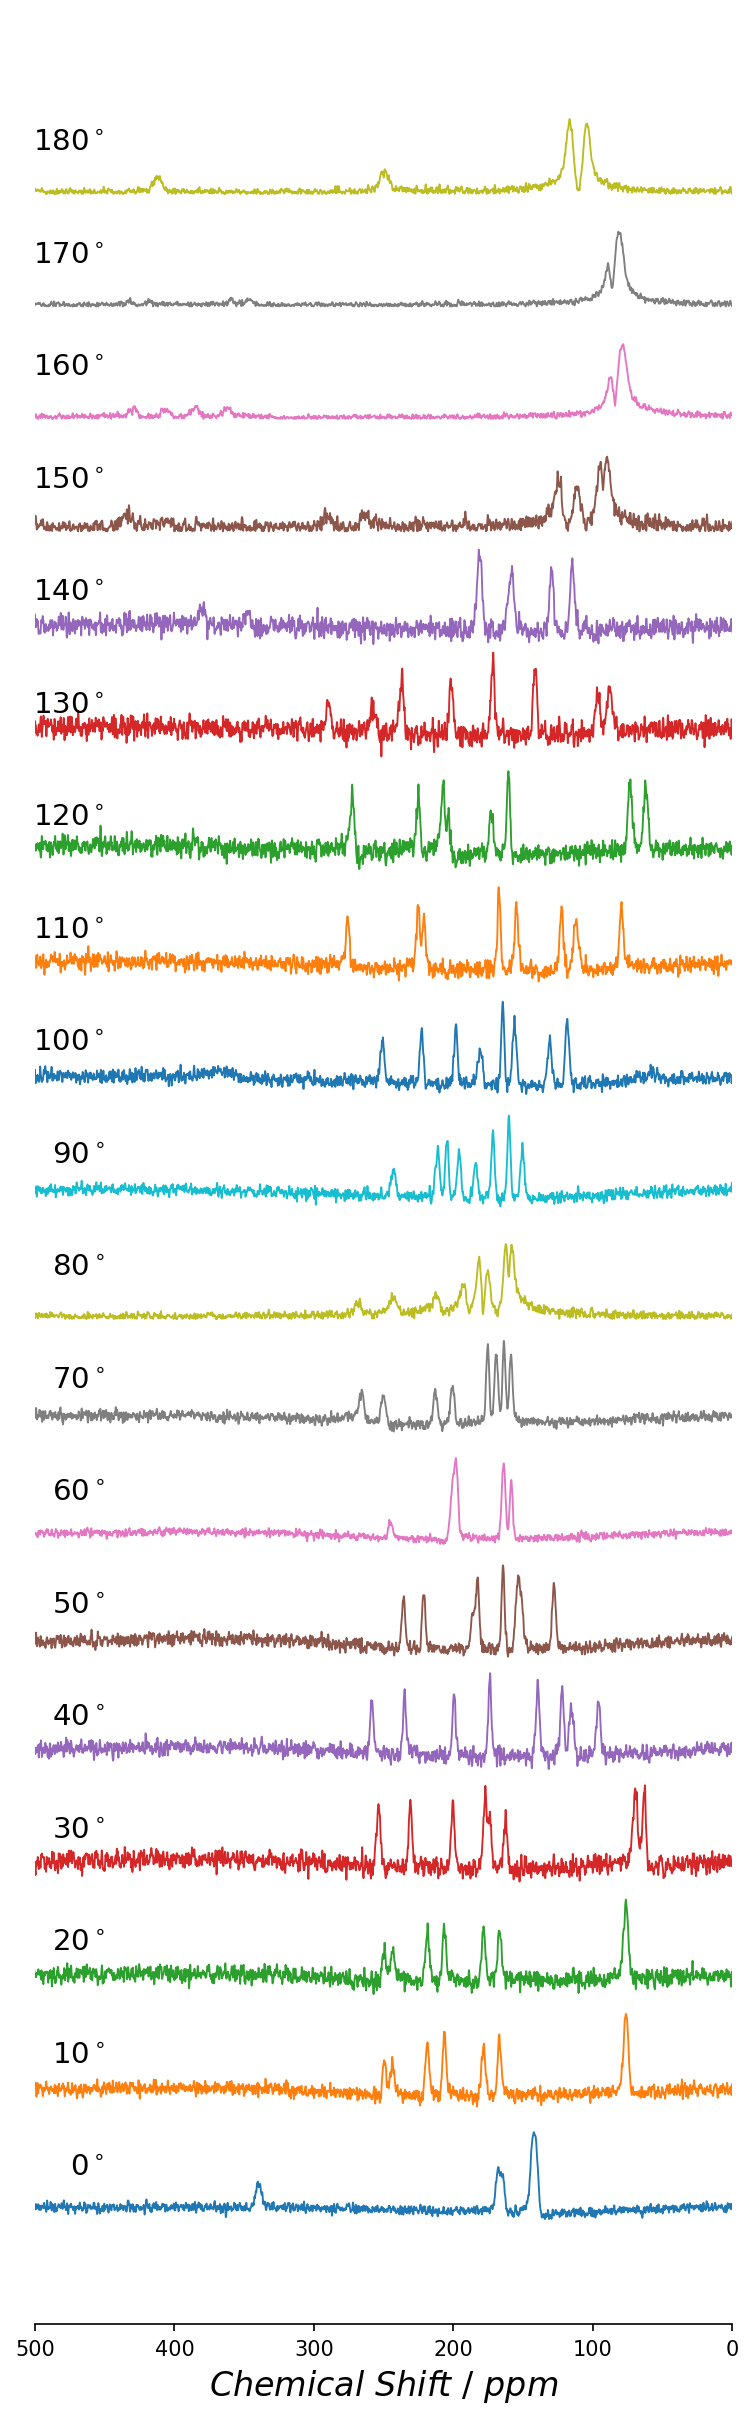

In [4]:
# Mapping for x_start and x_end for each file
# x_ranges = {
#     400: {"x_start": 2451.1, "x_end": -2465.6},
#     401: {"x_start": 2451, "x_end": -2465.6},
#     402: {"x_start": 2451, "x_end": -1050.5},
#     403: {"x_start": 607.3, "x_end": -621.8},
#     404: {"x_start": 1221.9, "x_end": -1050.5},
#     405: {"x_start": 1221.9, "x_end": -1050.5},
#     406: {"x_start": 1221.9, "x_end": -1050.5},
#     407: {"x_start": 607.3, "x_end": -621.8},

#     409: {"x_start": 607.3, "x_end": -621.8},
#     410: {"x_start": 607.3, "x_end": -621.8},
#     411: {"x_start": 607.3, "x_end": -621.8},
#     412: {"x_start": 607.3, "x_end": -621.8},
#     413: {"x_start": 607.3, "x_end": -621.8}
# }
# Define a common x-axis scale
data_sets = []

# Initialize a list to store resampled data


for numb in range(file_start, file_end + 1):
    if numb in skip_file:
        continue  # Skip the specified file
    
    # Load the data and normalize
    yData = np.loadtxt(path + "SW_Shiva" + str(numb) + ".txt", unpack=True)
    yData = yData / max(yData)  # Normalize
    yData = yData - min(yData)  # Remove vertical offset

    # Calculate x-axis
    steps = len(yData)
    x_start = 730.3                               #value from data file
    x_end = -498.9                                #value from data file
    steps_ppm = (x_end - x_start)/steps
    x = np.arange(x_start, x_end, steps_ppm)

    # Sotre x and y axis as data sets

    data_sets.append({"x": x, "y": yData})
    
# # Plot the data ********************************
fig, ax = plt.subplots(figsize=(6, 20), dpi=150)  # Create the figure and axes
labels = [rf"${i}^\circ$" for i in range(angle_start, angle_end + angle_step, angle_step)]

# # Plot each dataset with its corresponding x-axis
for i, (dataset, label) in enumerate(zip(data_sets, labels)):
    
#     # Calculate vertical offset
    offset = i * 1.5  # Adjust the offset value as needed
    
#     # Plot the data
    ax.plot(dataset["x"], dataset["y"] + offset, linewidth=0.9, label=label)
    
    # Add label text (adjust the position of label if needed)
    ax.text(x=450, y=offset+0.7,  s=label, color='black', va='center', ha='right', fontsize=14)

# Adjust plot aesthetics
ax.set_yticks([])  # Remove y-axis ticks
# ax.set_xlim([max(x_end, x_start), min(x_start, x_end)])  # Ensure proper limits for x-axis
ax.set_xlim([500, 0])  # Ensure proper limits for x-axis
ax.set_xlabel(r'$Chemical\ Shift\ /\ ppm$', fontsize=16)

# Hide the top spine
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.show()

# Save figure

fig.savefig('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/NMR_analysis/plots_experiment/X_stacked_D_alanine.png', dpi = 150 ,bbox_inches='tight')
